In [141]:
# Import Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Parallel Coordinate Plot
from pandas.plotting import parallel_coordinates as pcp
from matplotlib.patches import Patch

## **Part One**

In [142]:
# Import and select data
df = pd.read_csv("College Data.csv")

# Create two new data frames per instructions
df_10 = df.iloc[:10]
df_200 = df.iloc[:200]

# Check to make sure dataframes are correct 
print(df_10.shape)
print(df_200.shape)

(10, 15)
(200, 15)


In [143]:
# Examine data
df_10.head(3)

,world_rank,university_name,country,continent,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,female
0,1,California Institute of Technology,United States of America,North_America,95.6,64.0,97.6,99.8,97.8,95.1,2243.0,6.9,27.0,33 : 67,33.0
1,2,University of Oxford,United Kingdom,Europe,86.5,94.4,98.9,98.8,73.1,94.2,19919.0,11.6,34.0,46 : 54,46.0
2,3,Stanford University,United States of America,North_America,92.5,76.3,96.2,99.9,63.3,93.9,15596.0,7.8,22.0,42 : 58,42.0


### Task One

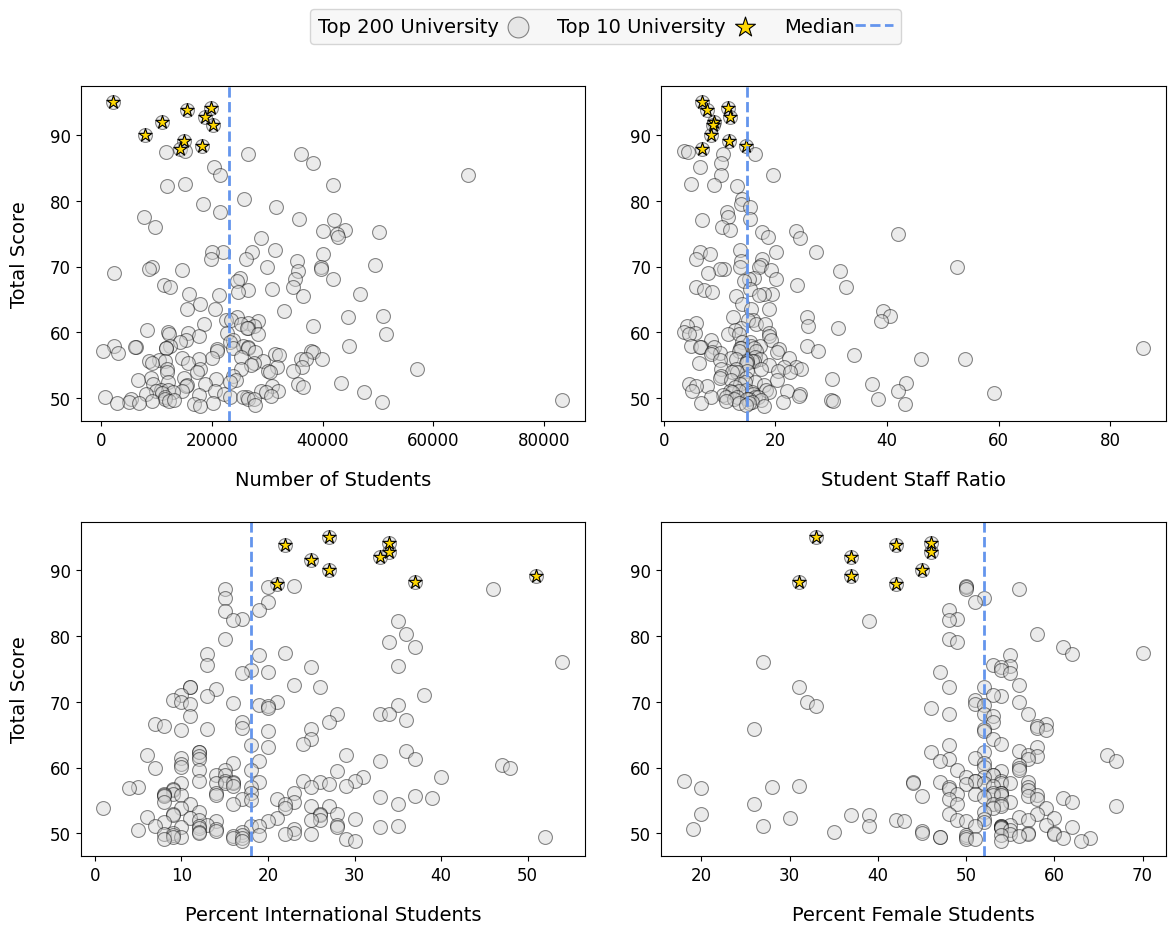

In [151]:
f, axes = plt.subplots(2, 2, figsize = [14, 10], gridspec_kw = {'wspace':0.15, 'hspace':0.3})
axes = axes.flatten()

y_var = "total_score"
y_labels = ["Number of Students", "Student Staff Ratio", "Percent International Students", "Percent Female Students"]
x_vars = ["num_students", "student_staff_ratio", "international_students", "female"]

# Loop to create the plots
for i in range(len(axes)):
    sns.scatterplot(data = df_200, x = x_vars[i], y = y_var, s = 100, alpha = 0.45, 
                    ec = 'k', ax = axes[i], color = 'lightgray', label = "Top 200 University")
    sns.scatterplot(data = df_10, x = x_vars[i], y = y_var, s = 100, alpha = 1, 
                    ec = 'k', ax = axes[i], marker="*", color = 'gold', label = "Top 10 University")
    
    # Add axvline 
    axes[i].axvline(x=df_200[x_vars[i]].median(), color='cornflowerblue', 
                    linestyle='--', linewidth=2, label='Median')
    
    # Print X-labels only on graphs on the left 
    if i == 2 or i == 0:
        axes[i].set_ylabel('Total Score', fontsize = 14, labelpad = 15)
    else:
        axes[i].set_ylabel('')
    axes[i].set_xlabel(y_labels[i], fontsize = 14, labelpad = 15)
    axes[i].tick_params(labelsize = 12)
    
    # Print Legend on top
    if i != 1:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(fontsize = 14, markerfirst = False, ncol = 3, bbox_to_anchor = [0.5,0.94],
                       markerscale = 1.5, columnspacing = 1, handletextpad = 0, facecolor = 'whitesmoke',
                       bbox_transform = f.transFigure, loc = 'center')

plt.savefig('scatter.png', bbox_inches = 'tight', facecolor = 'white')
plt.show()

### Task Two

In [145]:
# Calculate correlation coeff

# Total Score x Students 
stu_corr = df_200['num_students'].corr(df_200['total_score'])
print(f"Total Score x Students: {stu_corr:.4f}")

# Total Score x Student staff ratio
staff_corr = df_200['student_staff_ratio'].corr(df_200['total_score'])
print(f"Total Score x Staff Ratio: {staff_corr:.4f}")

# Total Score x International students 
int_corr = df_200['international_students'].corr(df_200['total_score'])
print(f"Total Score x International Students: {int_corr:.4f}")

# Total Score x female students 
fem_corr = df_200['female'].corr(df_200['total_score'])
print(f"Total Score x Female Students: {fem_corr:.4f}")

Total Score x Students: 0.0764
Total Score x Staff Ratio: -0.2121
Total Score x International Students: 0.2715
Total Score x Female Students: -0.1269


### Task 2 Written Answers

**A:** The correlation coefficients more or less match what is depicted in the graphs. The coefficients are the linear trends and when comparing them to the graphs they seem to match whether the trend is positive or negative. The correlations could be misleading as we are only looking at a subset of the data, so overall correlation across the data may look different. Furthermore, there are some clear outliers in this data that can pull the coefficients in certain directions this would play a major role in skewing the data. 

**B:** The top 10 universities are clustered together and to the same side of the median across all plots. In comparisons to the other data (top 200) they have much fewer outliers as in top 10 universities that lie far away from the central cluster. Regarding "number of students" they all fall below the median under the 20,000 range. They also all have quite a small student staff ratio under 18. Their percentage of international students does vary, however, they all fall well above the median. Lastly, all the top 10 universities have a lower percentage of female student falling well below the median.

## **Part Two**

### Task One

In [146]:
# Concat top 200 and bottom 200
last_200 = df.iloc[-200:]

first_last = pd.concat([df_200,last_200]).reset_index()

# Create new column 
first_last['Ranks'] = ['top']*200 + ['last']*200

first_last.tail(3)

,index,world_rank,university_name,country,continent,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,female,Ranks
397,797,601-800,Yokohama City University,Japan,Asia,24.0,16.1,10.2,36.4,37.9,23.3,4122.0,3.7,3.0,NaN,NaN,last
398,798,601-800,Yokohama National University,Japan,Asia,20.1,23.3,16.0,13.5,40.4,17.6,10117.0,12.1,8.0,28 : 72,28.0,last
399,799,601-800,Yuan Ze University,Taiwan,Asia,16.2,17.7,18.3,28.6,39.8,21.3,8663.0,20.6,4.0,43 : 57,43.0,last


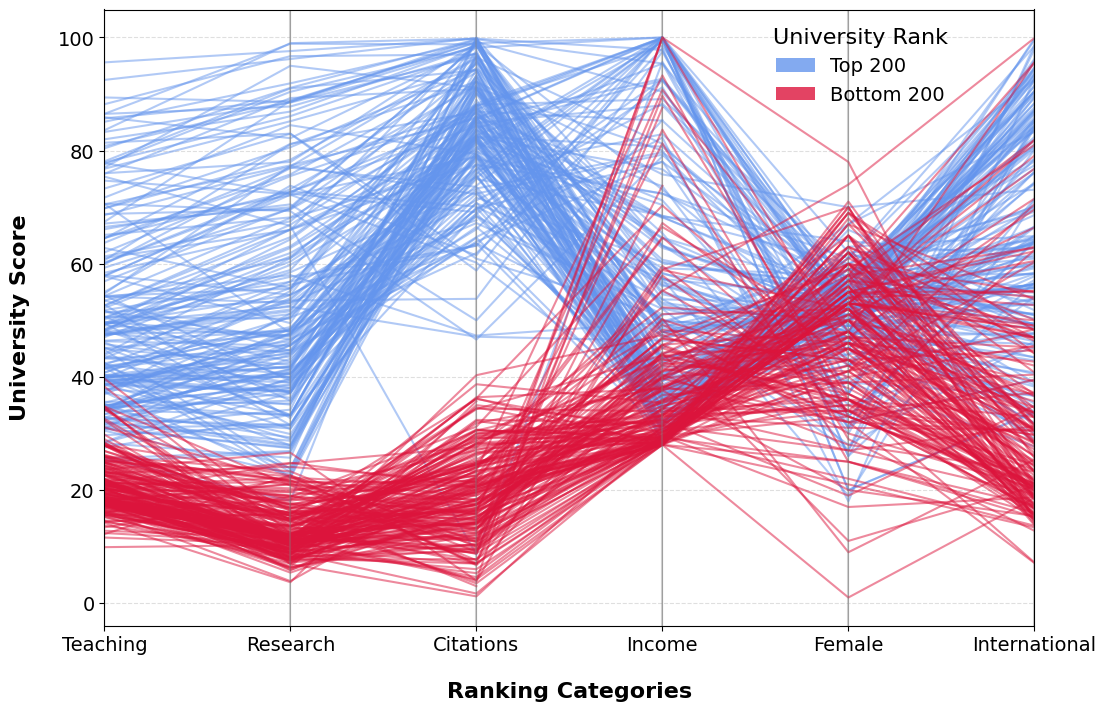

In [147]:
# Parallel Coordinate Plot

# Variables to plot
vars = ["teaching", "research", "citations", "income", "female", "international"]
df_plot = first_last[vars + ['Ranks']]

# Rename to title case 
df_plot = df_plot.rename(columns={'teaching': 'Teaching', 'research': 'Research', 
                                  'citations': 'Citations', 'income': 'Income', 
                                  'female': 'Female', 'international': 'International'})

plt.figure(figsize = [12,8])
colors = ['cornflowerblue', 'crimson']
pcp(df_plot, 'Ranks', color = colors, alpha = 0.5, axvlines_kwds={'alpha':0.35,'color':'grey'})
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis = 'y', alpha = 0.4, linestyle = '--')

# How to make a fake legend
handles = [Patch(facecolor=c, alpha = 0.8) for c in colors]
plt.legend(handles, ['Top 200','Bottom 200'], title='University Rank',
           bbox_to_anchor=(0.70,1.0), loc='upper left', fontsize = 14, title_fontsize = 16, frameon = False)
plt.ylabel('University Score', fontsize = 16, labelpad = 20, fontweight = 'bold')
plt.xlabel('Ranking Categories', fontsize = 16, labelpad = 20, fontweight = 'bold')

plt.savefig('parallel.png', bbox_inches = 'tight', facecolor = 'white')
plt.show()

### Task Two

**A:**  We didn’t standardize the data for the parallel coordinates plot. This is fine. Why? 

Because we want to preserve the original meaning of the variable and its absolute scale from comparisons. The variables we have are already on a 0-100 scale so there is no need to standardize them. 

**B:**  Which variables show the largest difference between the top and the last 200? Describe what 
you see in the plot briefly. Your answer should be based on your visualization, not any outside 
information. 

The largest difference I see in the plot is with the variable citations. There is a large gap between the top 200 and bottom 200 universities there, where the top 200 universities consistently showcase higher rates of citation. 

**C:** What you saw in B was largely expected. Why is this? (Hint: use the graphic that shows how 
scores were calculated) 

The graphic indicates that citations (research influence) make up almost a third of a universities score (30%). Because this ranking category is so large and holds a lot of weight it makes sense that the most separation between categories would be here.

## **Part Three**

### Task One

In [148]:
# Transform data
# Remove outliers as taught in Data 201

# Select numeric columns
num_cols = x_vars


# Cap outliers at 5th and 95th percentiles for each numeric column
for col in num_cols:
    lower = df[col].quantile(0.01)     # 1%
    upper = df[col].quantile(0.99)     # 99%
    df[col] = np.where(df[col] < lower, lower,
                        np.where(df[col] > upper, upper, 
                        df[col]))


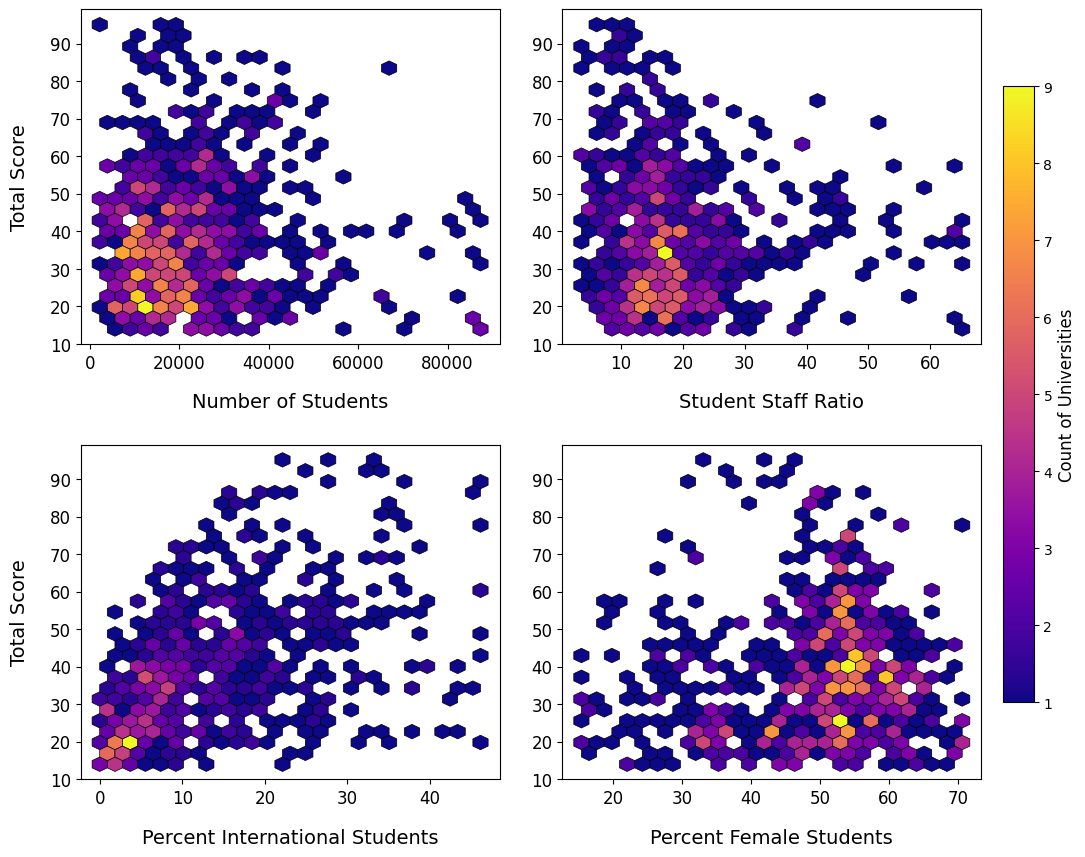

In [152]:
# Use all of the college data

f, axes = plt.subplots(2, 2, figsize = [14, 10], gridspec_kw = {'wspace':0.15, 'hspace':0.3})
axes = axes.flatten()

y_var = "total_score"
y_labels = ["Number of Students", "Student Staff Ratio", "Percent International Students", "Percent Female Students"]
x_vars = ["num_students", "student_staff_ratio", "international_students", "female"]

# Loop to create the plots
for i in range(len(axes)):
    hb = axes[i].hexbin(df[x_vars[i]], df[y_var], 
                        gridsize=25, mincnt=1, edgecolors='k', linewidths=0.5, cmap = 'plasma')
    
    # Print X-labels only on graphs on the left 
    if i == 2 or i == 0:
        axes[i].set_ylabel('Total Score', fontsize = 14, labelpad = 15)
    else:
        axes[i].set_ylabel('')
    axes[i].set_xlabel(y_labels[i], fontsize = 14, labelpad = 15)
    axes[i].tick_params(labelsize = 12)


cb = f.colorbar(hb, ax=axes.tolist(), shrink=0.8, location='right', pad=0.02)
cb.set_label('Count of Universities', fontsize=12)

plt.savefig('hex.png', bbox_inches = 'tight', facecolor = 'white')
plt.show()

### Task Two

**A:** For each of the plots, where is most of the data concentrated in the binning plot? What does this mean 
in terms of the values of the variables? What trends (if any) do you see in the data? Which variables 
have no trends?

Most of the data falls in bins 1-3 indicated by a darker purple and blue color. This indicates that there is little clustering and more unique values within the data. All graphs except for the "Percent Female" students graph have data clustered in the lower left of the plot and appear to exhibit some positive trend. The variable that showcases the least trend is the "female" variable. The data for the "female" variable is distributed a little more generally across the plot. 